In [43]:
#IMPORTAZIONE DELLE LIBRERIE

import numpy as np
import random as rd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [44]:
#DEFINIZIONI
percorso="/Users/carmelo/Desktop/Università/III ANNO/Lab di Fisica Moderna/Esperienze/Dualismo_Onda-Particella/Analisi_Dati/immagini/"

In [45]:
#DEFINIZIONE FUNZIONE ANALISI

def analisi(nome_file):
    
    #estrae dal nome i dati
    voltaggio_text=nome_file[0:4]
    voltaggio=float(voltaggio_text)
    print(voltaggio)
    set_text=nome_file[5:-5]
    print(set_text)

    #apre l'immagine e la converte in bianco e nero
    immagine=Image.open(percorso+nome_file)
    matrice_a_colori=np.array(immagine)
    matrice_bn=np.float64(np.array(immagine.convert('L')))
    
    #trova le coordinate riga colonna del massimo di intensità
    old_coords = np.unravel_index(np.argmax(matrice_bn), matrice_bn.shape)
    old_R_centro=old_coords[0]
    old_C_centro=old_coords[1]

    #lato medio dell'immagine (perché non è esattamente quadrata)
    lato_medio=np.mean(matrice_bn.shape)

    #rapporto per convertire in seguito
    pixel_in_mm=100/np.mean(matrice_bn.shape)

    #taglio in modo tale che il centro trovato corrisponda al centro della matrice
    cut_matrice_bn=matrice_bn[int(old_R_centro-0.4*lato_medio):int(old_R_centro+0.4*lato_medio), int(old_C_centro-0.4*lato_medio):int(old_C_centro+0.4*lato_medio)]

    #coordinate del nuovo centro
    coords = np.unravel_index(np.argmax(cut_matrice_bn), cut_matrice_bn.shape)
    R_centro=coords[0]
    C_centro=coords[1]

    #lato della nuova matrice tagliata
    lato=cut_matrice_bn.shape[0]

    #vecchio plot
    '''    
    plt.scatter(C_centro, R_centro, marker='X', c='r', s=0.5)
    plt.imshow(cut_matrice_bn)
    '''

    # ''asse delle x'' ovvero indice di colonna
    R_Mesh =np.linspace(0, lato-1, lato)

    #array con la riga e la colonna passanti per il centro
    Intensita_riga_centro=cut_matrice_bn[R_centro, :]
    Intensita_colonna_centro=cut_matrice_bn[:, C_centro]

    #valore nel centro
    Intensita_centro=cut_matrice_bn[R_centro,C_centro]

    #vecchio plot
    ''' 
    plt.plot(R_Mesh,Intensita_riga_centro)
    plt.plot(R_Mesh,Intensita_colonna_centro)
    plt.legend(('riga', 'colonna'))
    plt.title('Intensità passante per il centro (hehe passante)')
    plt.scatter(C_centro,
                Intensita_centro,
                c='r')
    '''

    #sovrapposizione
    somma=Intensita_colonna_centro+Intensita_riga_centro
    
    #fold della destra sulla sinistra
    somma_dx=np.flip(somma[:R_centro])
    somma_sx=somma[R_centro:]
    if(somma_sx.shape!=somma_dx.shape):
        somma_sx=np.append(somma_sx, (0))
    somma_fold=somma_dx+somma_sx
    somma_fold=somma_fold/max(somma_fold)
    
    #plot del risultato
    plt.title(voltaggio_text+' Volt ---'+' Set '+set_text)
    plt.plot(R_Mesh[:R_centro], somma_fold)
    plt.ylim(0,1)


    return R_Mesh[:R_centro], somma_fold, voltaggio, set_text, pixel_in_mm

#RITORNA TUTTO QUELLO CHE SERVE PER PLOTTARE

3600.0
c2


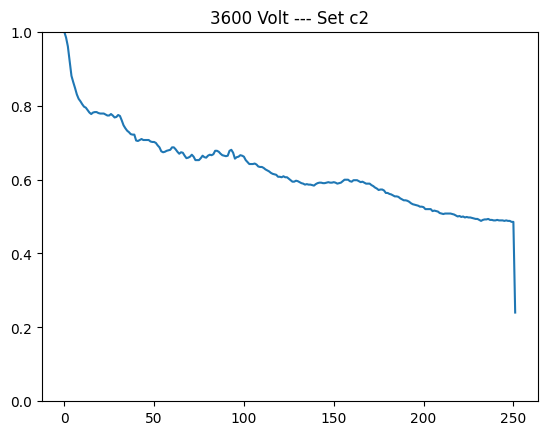

2900.0
c2


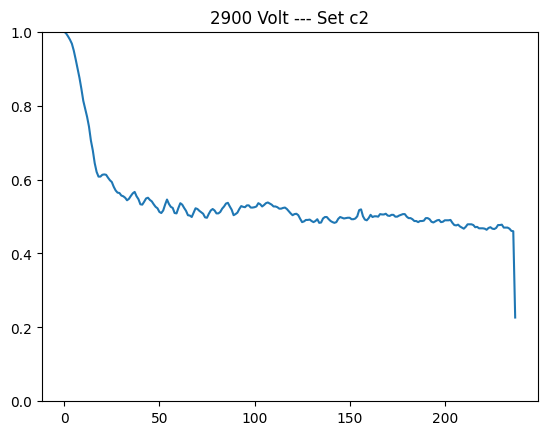

4500.0
v


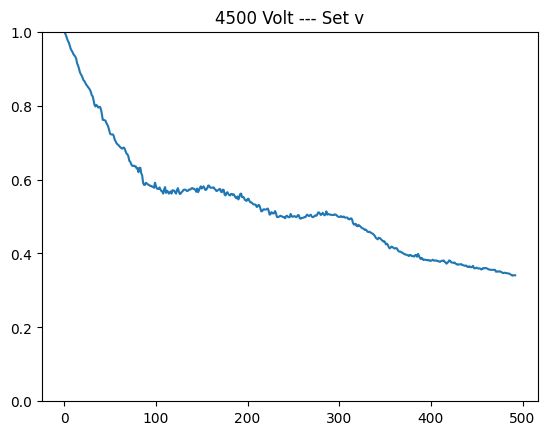

3800.0
v


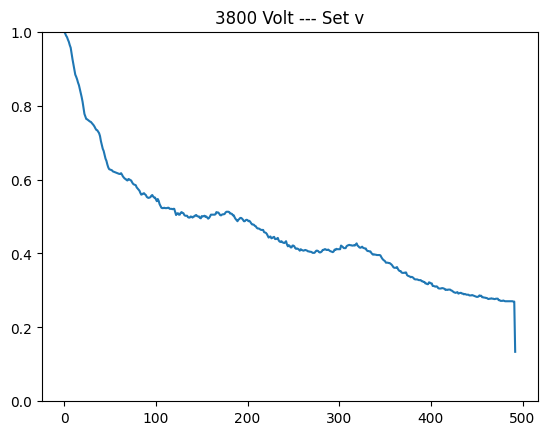

3400.0
v


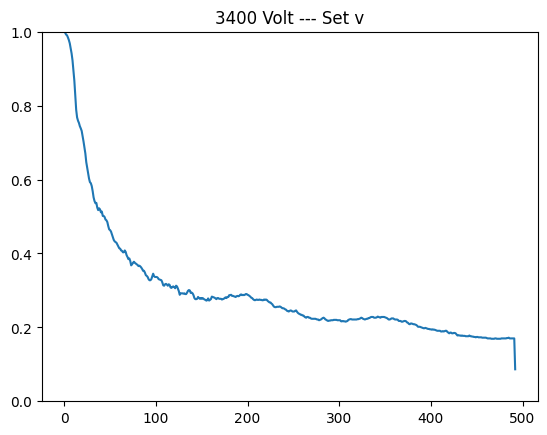

4000.0
c2


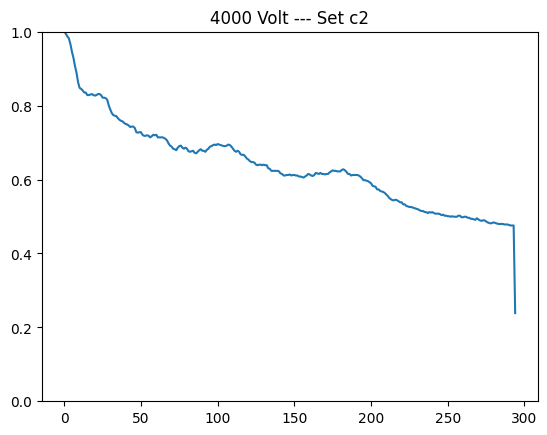

4500.0
c1


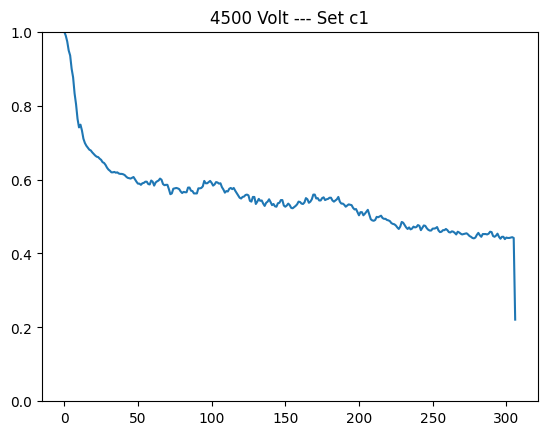

4050.0
c1


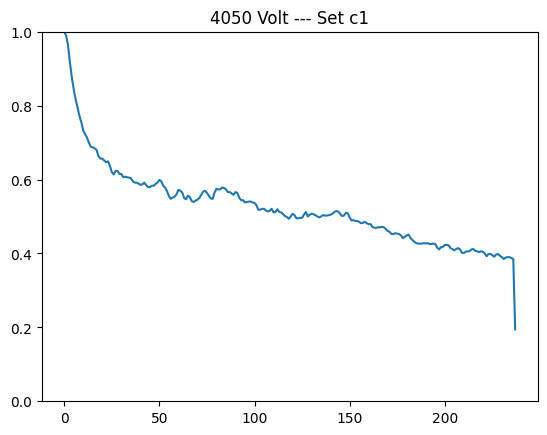

3900.0
c1


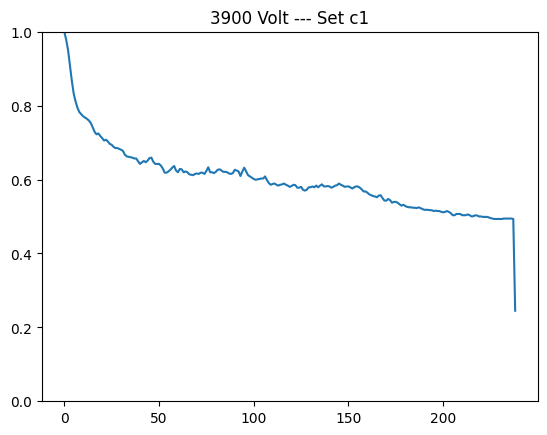

4550.0
c2


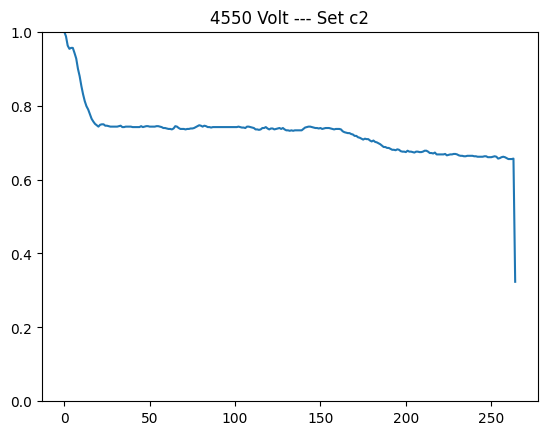

3750.0
c2


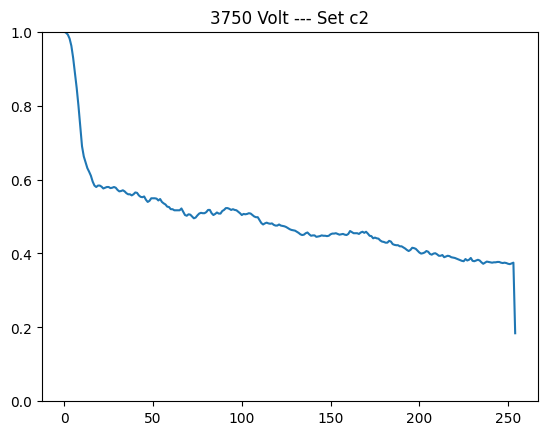

4350.0
c1


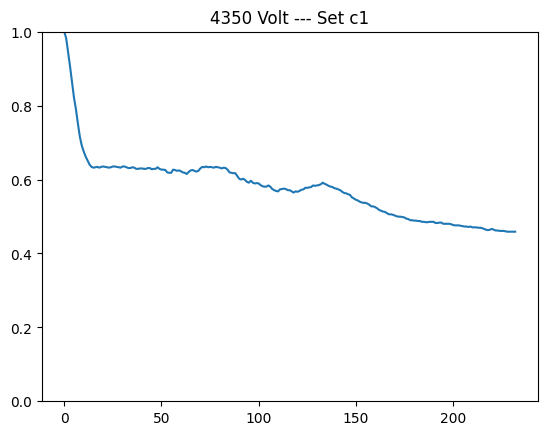

3200.0
c2


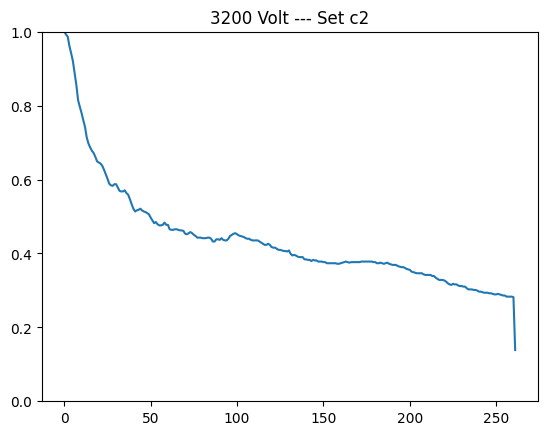

4350.0
v


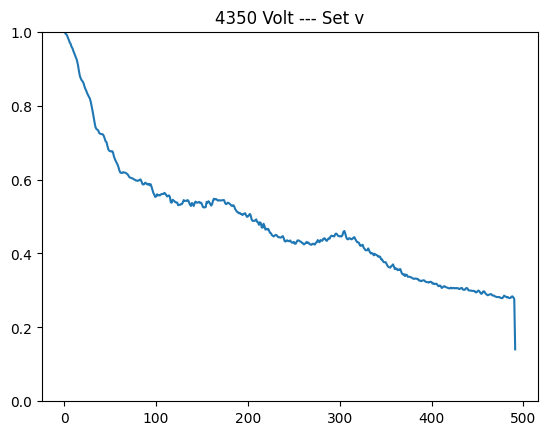

4200.0
c2


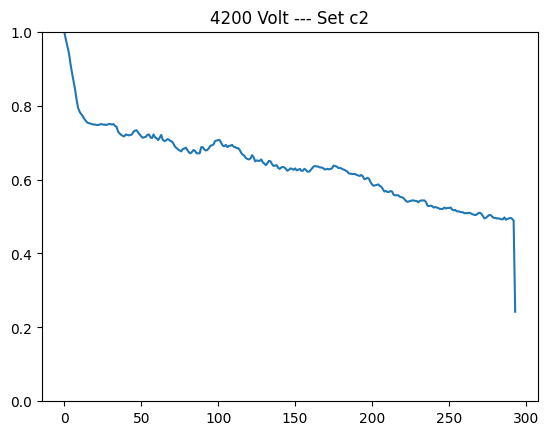

3600.0
c1


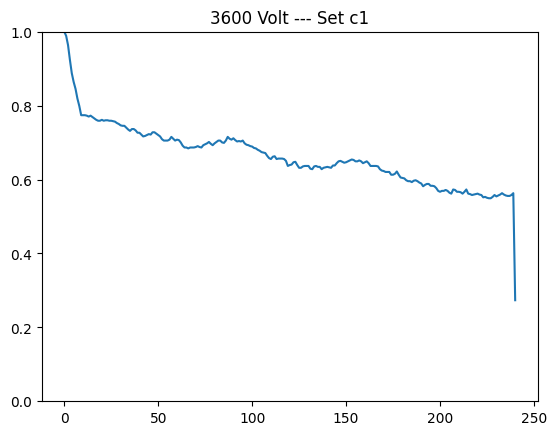

4100.0
v


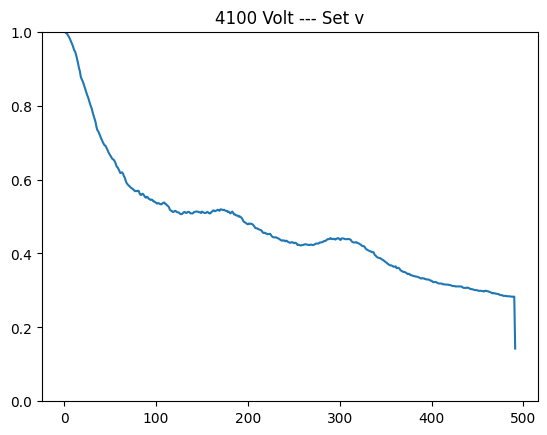

3300.0
c2


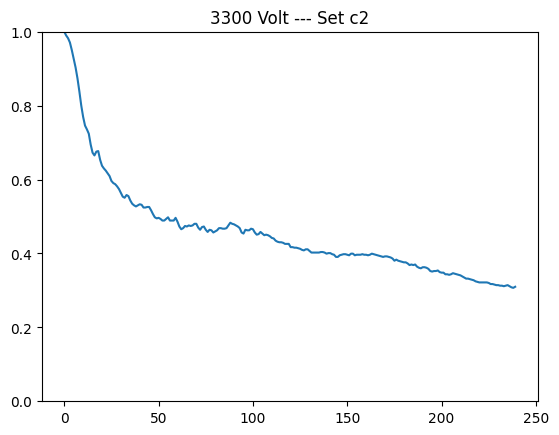

In [46]:
#CARICO TUTTI I RISULTATI IN UN DIZIONARIO DI DIZIONARI

risultati={}

for nome_file in os.listdir(percorso):
    risultati[nome_file]={}

    x, y, v, s, c = analisi(nome_file)
    
    risultati[nome_file]['R_Mesh']=x
    risultati[nome_file]['Fold']=y
    risultati[nome_file]['Voltaggio']=v
    risultati[nome_file]['Set']=s
    risultati[nome_file]['Pixel_in_mm']=c

    plt.show()

In [47]:
#funzione da gemini, concettualmente semplice ma non ho ancora masterato le maschere in PY
def taglia_dati(x, y, x_min, x_max):
    """
    Sotto-campiona gli array x e y in base a un intervallo definito su x.
    
    Parametri:
    x (np.ndarray): Array delle coordinate indipendenti (es. raggio).
    y (np.ndarray): Array delle coordinate dipendenti (es. intensità).
    x_min (float): Valore minimo dell'intervallo.
    x_max (float): Valore massimo dell'intervallo.
    
    Ritorna:
    tuple: (x_filtrato, y_filtrato) come np.ndarray.
    """
    # Creazione di una maschera booleana
    maschera = (x >= x_min) & (x <= x_max)
    
    # Applicazione della maschera a entrambi gli array
    return x[maschera], y[maschera]

# Esempio di utilizzo:
# r = np.linspace(0, 10, 100)
# i = np.exp(-r**2)
# r_tagliato, i_tagliato = taglia_dati(r, i, 2.0, 5.0)



def media_mobile_conv(y, finestra):
    """
    Calcola la media mobile utilizzando la convoluzione.
    y: array dei dati (intensità).
    finestra: numero di punti della finestra di media.
    """
    kernel = np.ones(finestra) / finestra
    # 'same' mantiene la dimensione dell'array originale
    return np.convolve(y, kernel, mode='same')

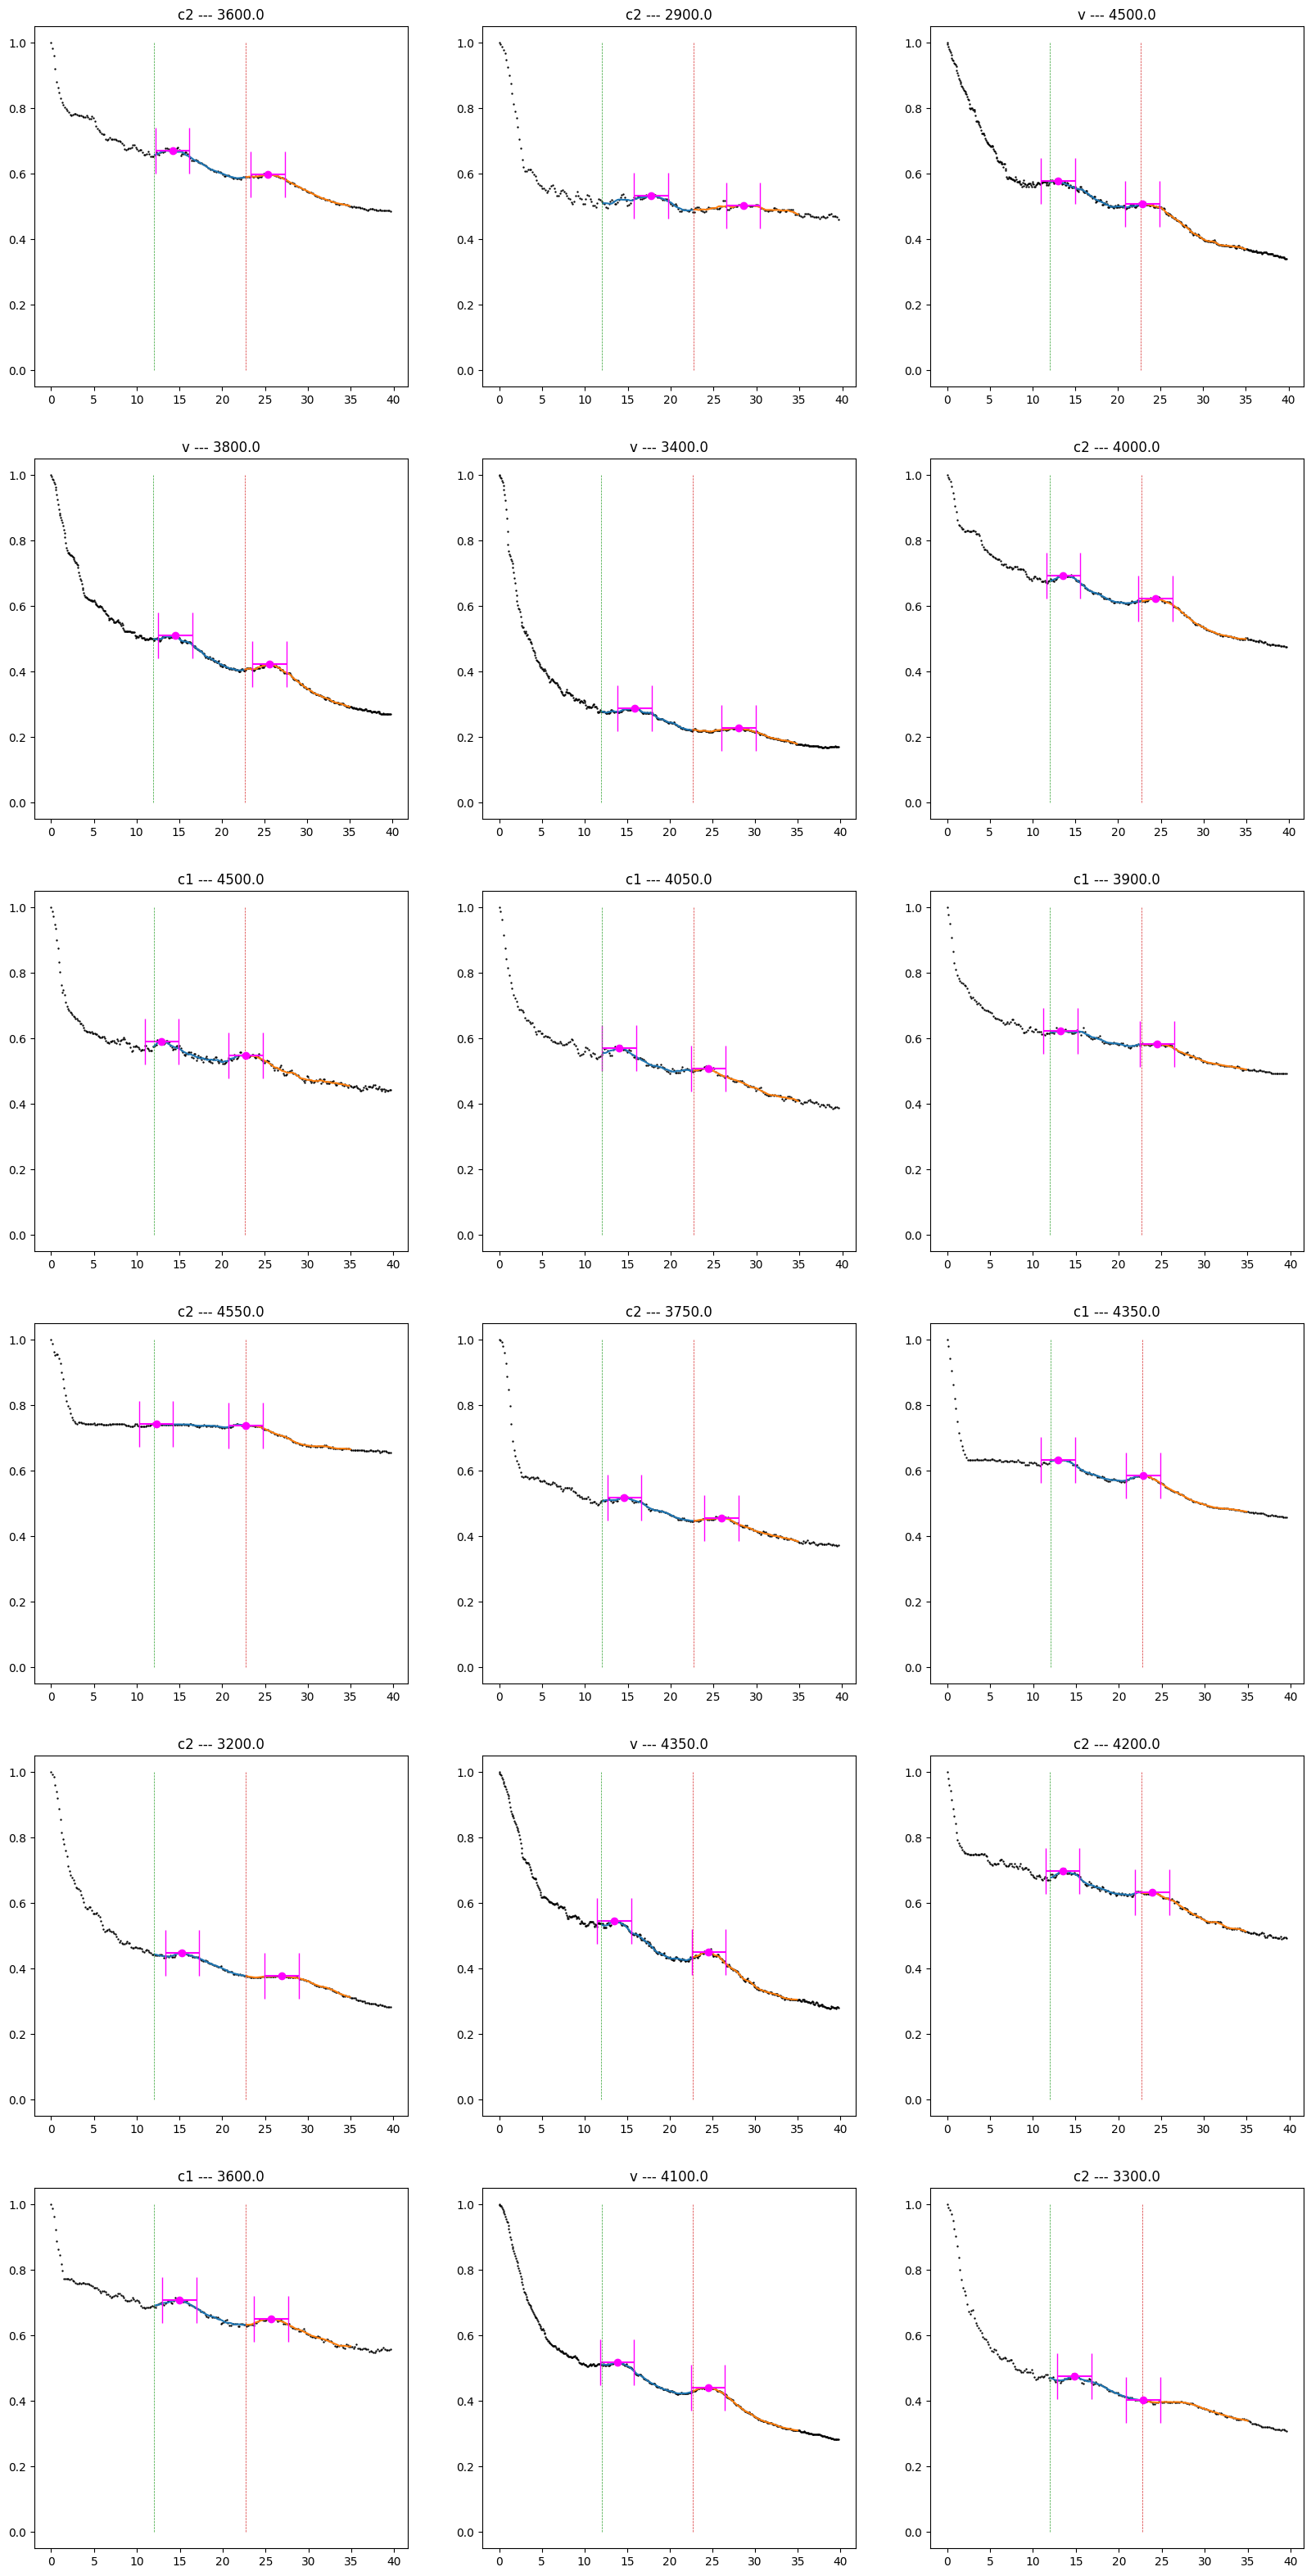

In [48]:
#LOCALIZZAZIONE GRAFICA DEI MASSIMI

#DEFINIZIONI ARBITRARIE (GRAFICHE):
i=0
retta_1=12
retta_2=22.7
err=2

#apertura figura
plt.figure(figsize=(20,40), dpi=100)

#ciclo for su tutti i dati
for file in risultati:    
    
    #trimming dei dati e conversione delle x in mm
    x=risultati[file]['R_Mesh'][:-2]
    x=x*risultati[file]['Pixel_in_mm']
    y=risultati[file]['Fold'][:-2]
    #array di y passato sotto la media mobile
    y_med=media_mobile_conv(y, 9)

    #fette di dati tra le rette di soglia definite arbitrariamente
    cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
    cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, 35)

    #immagine
    plt.subplot(6,3,i+1)
    plt.title(risultati[file]['Set']+' --- '+str(risultati[file]['Voltaggio']))
    
    #dati originari
    plt.scatter(x, 
                y,
                s=.5, 
                c='black')

    #fette di dati passate sotto media mobile
    plt.plot(cut_1_x, cut_1_y)
    plt.plot(cut_2_x, cut_2_y)   

    #indici dei massimi locali all'interno delle fette
    max_1=np.argmax(cut_1_y)
    max_2=np.argmax(cut_2_y)
    
    #inserimento dei massimi
    plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='magenta', capsize=20, marker='o')    
    plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='magenta', capsize=20, marker='o')
    
    #plot delle rette
    plt.plot((retta_1,retta_1), (0,1), ls='--', linewidth=0.5)
    plt.plot((retta_2,retta_2), (0,1), ls='--', linewidth=0.5)
    
    #carica i due massimi nel dizionario di dizionari
    risultati[file]['R10']=cut_1_x[max_1]
    risultati[file]['R11']=cut_2_x[max_2]

    #i++
    i+=1

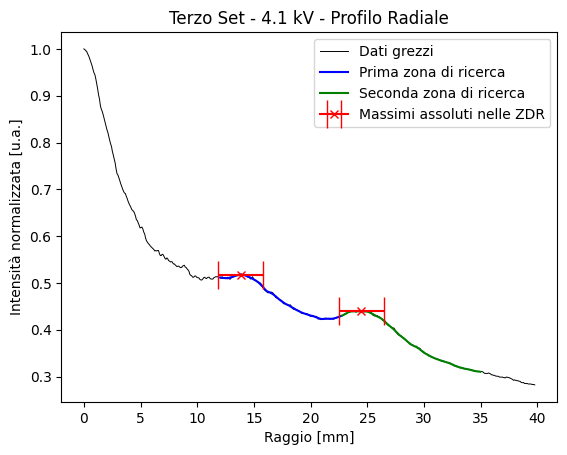

In [49]:
#PLOT ESEMPLIFICATIVO PER UN FILE
file='4100_v.jpeg'

x=risultati[file]['R_Mesh'][:-2]
x=x*risultati[file]['Pixel_in_mm']
y=risultati[file]['Fold'][:-2]

#array di y passato sotto la media mobile
y_med=media_mobile_conv(y, 9)

#fette di dati tra le rette di soglia definite arbitrariamente
cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, 35)
plt.title('Terzo Set - 4.1 kV - Profilo Radiale')
plt.xlabel('Raggio [mm]')
plt.ylabel('Intensità normalizzata [u.a.]')

#dati originari
plt.plot(x, 
            y,
            linewidth=.7, 
            c='black')

#fette di dati passate sotto media mobile
plt.plot(cut_1_x, cut_1_y, c='blue')
plt.plot(cut_2_x, cut_2_y, c='green')   

#indici dei massimi locali all'interno delle fette
max_1=np.argmax(cut_1_y)
max_2=np.argmax(cut_2_y)

#inserimento dei massimi
plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='red', capsize=10, marker='x')    
plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='red', capsize=10, marker='x')

plt.legend(('Dati grezzi', 'Prima zona di ricerca', 'Seconda zona di ricerca', 'Massimi assoluti nelle ZDR'))


In [50]:
R10=[]
for file in risultati:
    R10.append((risultati[file]['R10']))
    print((risultati[file]['R10']))

14.171974522292993
17.67676767676768
12.981744421906694
14.535119772634998
15.922014622258326
13.586956521739129
12.93272370999347
13.973063973063974
13.243922883487008
12.263436790310372
14.611154752553023
12.875536480686696
15.313935681470136
13.512413512413511
13.48773841961853
14.962593516209477
13.826758845058967
14.833333333333332


In [51]:
R11=[]
for file in risultati:
    R11.append((risultati[file]['R11']))
    print((risultati[file]['R11']))

25.318471337579616
28.451178451178453
22.88032454361055
25.578562728380025
28.1072298943948
24.320652173913043
22.730241672109734
24.410774410774412
24.476110645431685
22.71006813020439
25.923016496465042
22.832618025751074
26.952526799387442
24.582824582824582
23.978201634877387
25.602660016625105
24.48149654331029
22.833333333333332


In [52]:
# Costanti fisiche
R_bulbo = 65.0               # Raggio del tubo in mm
d_10 = 2.13e-10              # Distanza piani reticolari (metri)
d_11 = 1.23e-10              # Distanza piani reticolari (metri)
h = 6.626e-34                # Costante di Planck (J*s)
m_e = 9.109e-31              # Massa elettrone (kg)
e_charge = 1.602e-19         # Carica elettrone (C)

# 1. Inversione della proiezione sferica per trovare l'angolo theta reale (in radianti)
# Il raggio misurato è r2d. Attenzione: arcsin richiede l'argomento <= 1.
theta_10 = 0.5 * np.arcsin(risultati[file]['R10'] / R_bulbo)
theta_11 = 0.5 * np.arcsin(risultati[file]['R11'] / R_bulbo)

# 2. Calcolo della lunghezza d'onda reale (Equazione di Bragg esatta)
lambda_10 = 2 * d_10 * np.sin(theta_10)
lambda_11 = 2 * d_11 * np.sin(theta_11)

# 3. Calcolo della Differenza di Potenziale reale (Postulato di de Broglie)
U_vera_10 = (h**2) / (2 * m_e * e_charge * (lambda_10**2))
U_vera_11 = (h**2) / (2 * m_e * e_charge * (lambda_11**2))

# Salvataggio nel dizionario per successiva regressione
risultati[file]['U_vera_10'] = U_vera_10
risultati[file]['U_vera_11'] = U_vera_11

In [53]:
import numpy as np
import scipy.stats as stats

# Costanti fisiche
L = 125.0                    # Distanza reticolo-schermo (mm)
R_bulbo = 65.0               # Raggio del tubo (mm)
d_10 = 2.13e-10              # Distanza piani reticolari (metri)
d_11 = 1.23e-10              # Distanza piani reticolari (metri)
h = 6.626e-34                # Costante di Planck (J*s)
m_e = 9.109e-31              # Massa elettrone (kg)
e_charge = 1.602e-19         # Carica elettrone (C)

# Liste per immagazzinare i dati del fit
U_mis_list = []
U_vera_10_list = []
U_vera_11_list = []

print(f"{'File':<15} | {'U_mis [V]':<10} | {'U_vera_10 [V]':<15} | {'U_vera_11 [V]':<15}")
print("-" * 65)

# Ciclo unico: calcola la correzione, salva i dati e stampa la tabella
for file in risultati:
    # 1. Recupero i raggi planari in mm dal dizionario
    r10_mm = risultati[file]['R10']
    r11_mm = risultati[file]['R11']
    
    # 2. Calcolo della profondità Z sul vetro curvo e dell'angolo reale
    z_10 = L - R_bulbo + np.sqrt(R_bulbo**2 - r10_mm**2)
    z_11 = L - R_bulbo + np.sqrt(R_bulbo**2 - r11_mm**2)
    
    theta_10 = 0.5 * np.arctan(r10_mm / z_10)
    theta_11 = 0.5 * np.arctan(r11_mm / z_11)
    
    # 3. Legge di Bragg per la lunghezza d'onda reale
    lambda_10 = 2 * d_10 * np.sin(theta_10)
    lambda_11 = 2 * d_11 * np.sin(theta_11)
    
    # 4. Postulato di de Broglie per la differenza di potenziale reale
    U_vera_10 = (h**2) / (2 * m_e * e_charge * (lambda_10**2))
    U_vera_11 = (h**2) / (2 * m_e * e_charge * (lambda_11**2))
    
    # 5. Salvataggio delle chiavi mancanti nel dizionario
    risultati[file]['U_vera_10'] = U_vera_10
    risultati[file]['U_vera_11'] = U_vera_11
    
    # 6. Estrazione della tensione misurata
    u_mis = risultati[file]['Voltaggio'] 
    
    # Popolamento liste per il fit
    U_mis_list.append(u_mis)
    U_vera_10_list.append(U_vera_10)
    U_vera_11_list.append(U_vera_11)
    
    # Stampa riga
    print(f"{file:<15} | {u_mis:<10.1f} | {U_vera_10:<15.1f} | {U_vera_11:<15.1f}")

# Regressione lineare: U_vera = k * U_mis + U_0
fit_10 = stats.linregress(U_mis_list, U_vera_10_list)
fit_11 = stats.linregress(U_mis_list, U_vera_11_list)

print("\n" + "="*65)
print("RISULTATI CALIBRAZIONE PARTITORE")
print("="*65)

print(f"Da Anello R10:")
print(f"Coefficiente angolare k : {fit_10.slope:.4f} ± {fit_10.stderr:.4f}")
print(f"Rapporto effettivo      : {fit_10.slope * 1000:.1f} : 1")
print(f"Termine noto U_0        : {fit_10.intercept:.1f} V")
print(f"R^2                     : {fit_10.rvalue**2:.4f}\n")

print(f"Da Anello R11:")
print(f"Coefficiente angolare k : {fit_11.slope:.4f} ± {fit_11.stderr:.4f}")
print(f"Rapporto effettivo      : {fit_11.slope * 1000:.1f} : 1")
print(f"Termine noto U_0        : {fit_11.intercept:.1f} V")
print(f"R^2                     : {fit_11.rvalue**2:.4f}")

File            | U_mis [V]  | U_vera_10 [V]   | U_vera_11 [V]  
-----------------------------------------------------------------
3600_c2.jpeg    | 3600.0     | 2540.2          | 2303.0         
2900_c2.jpeg    | 2900.0     | 1618.5          | 1797.5         
4500_v.jpeg     | 4500.0     | 3035.0          | 2847.8         
3800_v.jpeg     | 3800.0     | 2412.9          | 2253.9         
3400_v.jpeg     | 3400.0     | 2004.2          | 1844.9         
4000_c2.jpeg    | 4000.0     | 2767.2          | 2506.3         
4500_c1.jpeg    | 4500.0     | 3058.3          | 2887.2         
4050_c1.jpeg    | 4050.0     | 2614.2          | 2486.9         
3900_c1.jpeg    | 3900.0     | 2914.5          | 2473.0         
4550_c2.jpeg    | 4550.0     | 3405.7          | 2892.6         
3750_c2.jpeg    | 3750.0     | 2387.5          | 2191.0         
4350_c1.jpeg    | 4350.0     | 3085.9          | 2860.3         
3200_c2.jpeg    | 3200.0     | 2169.8          | 2017.4         
4350_v.jpeg     | 4350.0

<ErrorbarContainer object of 3 artists>

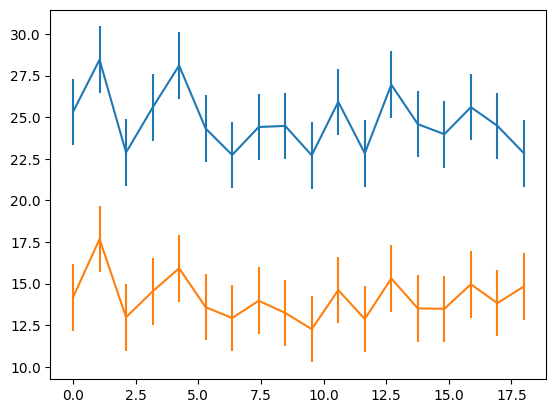

In [54]:
plt.errorbar(np.linspace(0, 18, 18), y=R11, yerr=2)
plt.errorbar(np.linspace(0, 18, 18), y=R10, yerr=2)